# 01 — EDA: Pekao SA + Revolut (real data)

Cel: zrozumieć rozkład klas, kwot i sezonowość w realnym zbiorze przed kolejną iteracją modelu klasyfikacji.
Ten notebook jest źródłem materiału do rozdziału ewaluacyjnego pracy magisterskiej.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
ROOT

WindowsPath('c:/Users/Kuba/Desktop/WSEI/WSEI 2 stopień IS/Sezon 2/Magisterka Projekt')

## 1. Wczytanie danych przez parsery

In [2]:
from finance.ingestion.pekao import PekaoParser
from finance.ingestion.revolut import RevolutParser
from finance.ml.classification.dataset import dtos_to_dataframe

PEKAO_PATH = ROOT / 'data' / 'pekao_sa' / 'styczen_kwiecien_2026_PekaoSA.csv'
REVOLUT_PATHS = list((ROOT / 'data' / 'revolut').glob('*.csv'))

all_dtos = []
with open(PEKAO_PATH, 'rb') as fh:
    all_dtos.extend(PekaoParser().parse(fh, PEKAO_PATH.name))
for p in REVOLUT_PATHS:
    with open(p, 'rb') as fh:
        all_dtos.extend(RevolutParser().parse(fh, p.name))

df = dtos_to_dataframe(all_dtos)
print(f'Total rows: {len(df)}')
print(f'Labelled  : {df["category"].notna().sum()}')
df.head()

Total rows: 167
Labelled  : 86


,text,abs_amount,day_of_week,category,merchant,title,source,booking_date,raw_category,direction
0,Orange Flex BLIK REF 93913364115,350.00,3,subscriptions,Orange Flex,BLIK REF 93913364115,pekao,2026-04-30,"Internet, TV, telefon",debit
1,ALLEGRO.PL BLIK REF 93904976498,24.23,2,other,ALLEGRO.PL,BLIK REF 93904976498,pekao,2026-04-29,Zakupy przez internet,debit
2,KLAUDIA DĄB Przelew na telefon 48797***131. Pr...,80.00,2,NaN,KLAUDIA DĄB,Przelew na telefon 48797***131. Przelew na tel...,pekao,2026-04-29,Sprzedaż,credit
3,ROBERT LIMONKA Przelew na telefon 48797***131....,50.00,1,NaN,ROBERT LIMONKA,Przelew na telefon 48797***131. Przelew na tel...,pekao,2026-04-28,Sprzedaż,credit
4,ANGELA HEBAN Przelew na telefon 48797***131. P...,350.00,5,NaN,ANGELA HEBAN,Przelew na telefon 48797***131. Przelew na tel...,pekao,2026-04-25,Sprzedaż,credit


## 2. Wiersze per źródło / per waluta / per kierunek

In [4]:
by_src = df.groupby('source').agg(
    rows=('text', 'count'),
    labelled=('category', lambda s: s.notna().sum()),
    debit=('direction', lambda s: (s == 'debit').sum()),
    credit=('direction', lambda s: (s == 'credit').sum()),
).reset_index()
by_src

,source,rows,labelled,debit,credit
0,pekao,140,86,101,39
1,revolut,27,0,17,10


## 3. Rozkład klas (etykietowanych)

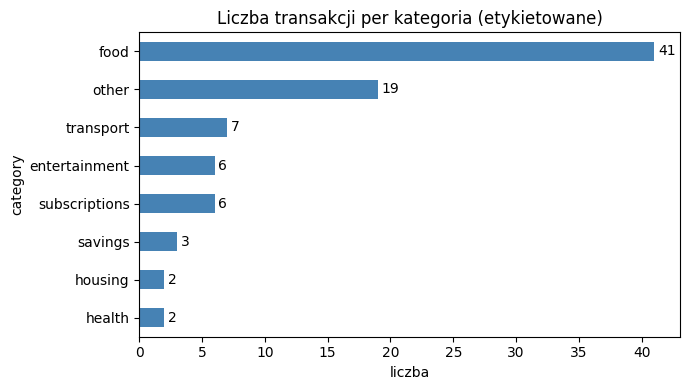

,n
category,
health,2
housing,2
savings,3
subscriptions,6
entertainment,6
transport,7
other,19
food,41


In [3]:
labelled = df[df['category'].notna()].copy()
class_counts = labelled['category'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot.barh(ax=ax, color='steelblue')
ax.set_title('Liczba transakcji per kategoria (etykietowane)')
ax.set_xlabel('liczba')
for i, v in enumerate(class_counts.values):
    ax.text(v + 0.3, i, str(v), va='center')
plt.tight_layout()
plt.show()
class_counts.to_frame('n')

## 4. Rozkład kwot per kategoria (boxplot)

C:\Users\Kuba\AppData\Local\Temp\ipykernel_12016\2155491136.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=order, showfliers=False)


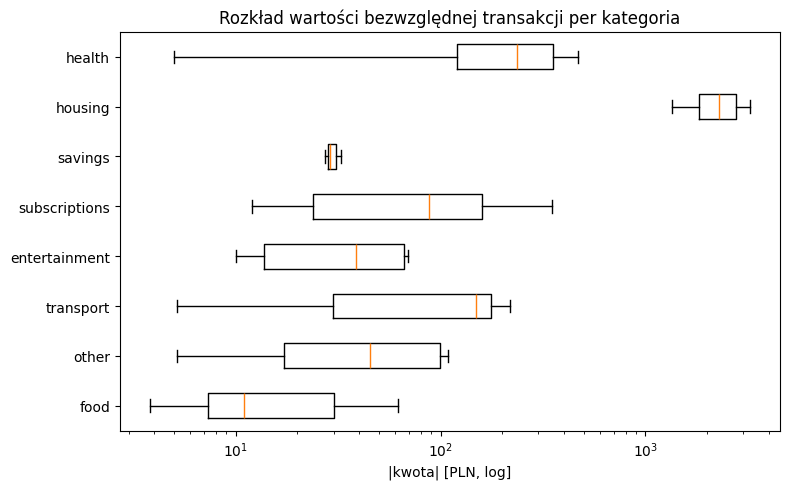

,count,mean,median,max
category,,,,
entertainment,6,73.12,38.49,270.76
food,41,22.22,10.98,120.98
health,2,236.50,236.50,468.00
housing,2,2294.59,2294.59,3240.18
other,19,192.26,45.00,928.20
savings,3,29.55,28.98,32.54
subscriptions,6,120.59,87.50,350.00
transport,7,112.28,149.57,219.35


In [ ]:
import numpy as np
fig, ax = plt.subplots(figsize=(8, 5))
order = class_counts.index.tolist()[::-1]
data = [
    np.asarray(labelled[labelled['category'] == c]['abs_amount'].to_numpy())  # type: ignore[union-attr]
    for c in order
]
ax.boxplot(data, vert=False, tick_labels=order, showfliers=False)
ax.set_xscale('log')
ax.set_xlabel('|kwota| [PLN, log]')
ax.set_title('Rozkład wartości bezwzględnej transakcji per kategoria')
plt.tight_layout()
plt.show()
labelled.groupby('category')['abs_amount'].agg(['count', 'mean', 'median', 'max']).round(2)

## 5. Sezonowość — wydatki w czasie

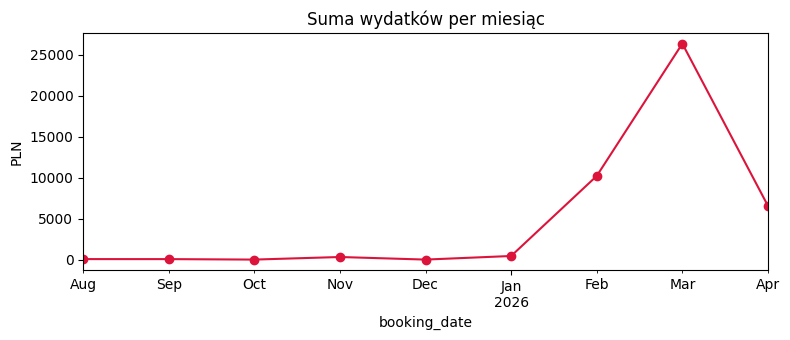

booking_date
2025-08-01       60.00
2025-09-01       57.24
2025-10-01        0.00
2025-11-01      314.98
2025-12-01        0.00
2026-01-01      438.89
2026-02-01    10212.33
2026-03-01    26370.03
2026-04-01     6566.41
Freq: MS, Name: abs_amount, dtype: float64

In [6]:
spend = df[df['direction'] == 'debit'].copy()
spend['booking_date'] = pd.to_datetime(spend['booking_date'])
monthly = spend.set_index('booking_date').resample('MS')['abs_amount'].sum()

fig, ax = plt.subplots(figsize=(8, 3.5))
monthly.plot(ax=ax, marker='o', color='crimson')
ax.set_title('Suma wydatków per miesiąc')
ax.set_ylabel('PLN')
plt.tight_layout()
plt.show()
monthly.round(2)

## 6. Heatmap: dzień tygodnia × kategoria

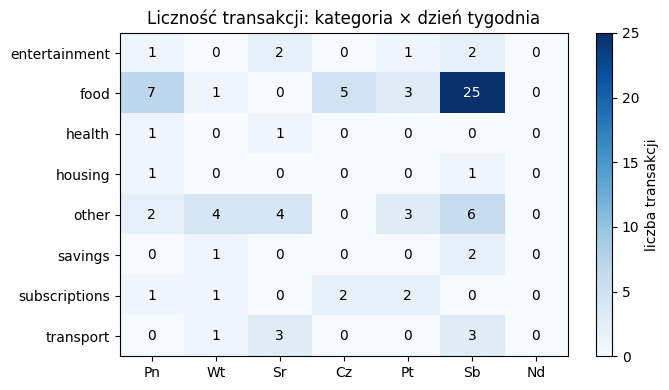

In [ ]:
DOW = ['Pn', 'Wt', 'Sr', 'Cz', 'Pt', 'Sb', 'Nd']
_dow_series = labelled['day_of_week'].dropna().astype(int).map(lambda i: DOW[int(i)])  # type: ignore[arg-type]
pivot = (
    labelled.assign(dow=_dow_series)
    .pivot_table(index='category', columns='dow', values='abs_amount', aggfunc='count', fill_value=0)
    .reindex(columns=DOW, fill_value=0)
).astype(int)
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(DOW))); ax.set_xticklabels(DOW)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
vmax = max(int(pivot.values.max()), 1)
for (i, j), v in np.ndenumerate(pivot.values):
    ax.text(j, i, str(int(v)), ha='center', va='center',
            color='black' if v < vmax / 2 else 'white')
fig.colorbar(im, ax=ax, label='liczba transakcji')
ax.set_title('Liczność transakcji: kategoria × dzień tygodnia')
plt.tight_layout()
plt.show()

## 7. Confusion matrix najlepszego klasyfikatora (CV out-of-fold)

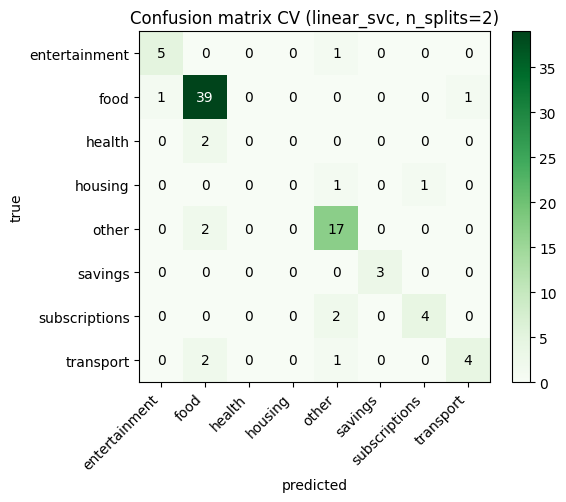

               precision    recall  f1-score   support

entertainment       0.83      0.83      0.83         6
         food       0.87      0.95      0.91        41
       health       0.00      0.00      0.00         2
      housing       0.00      0.00      0.00         2
        other       0.77      0.89      0.83        19
      savings       1.00      1.00      1.00         3
subscriptions       0.80      0.67      0.73         6
    transport       0.80      0.57      0.67         7

     accuracy                           0.84        86
    macro avg       0.63      0.61      0.62        86
 weighted avg       0.80      0.84      0.81        86



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from finance.ml.classification.pipeline import build_pipeline, REQUIRED_COLUMNS
from finance.ml.classification.registry import ESTIMATORS

min_per_class = 2
vc = labelled['category'].value_counts()
keep = vc[vc >= min_per_class].index
L = labelled[labelled['category'].isin(keep)].reset_index(drop=True)
X = L[REQUIRED_COLUMNS]
y = L['category']
n_splits = min(5, int(y.value_counts().min()))

best_name = 'linear_svc'
pipe = build_pipeline(ESTIMATORS[best_name]())
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipe, X, y, cv=skf)

labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Greens')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Confusion matrix CV ({best_name}, n_splits={n_splits})')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(int(v)), ha='center', va='center', color='black' if v < cm.max() / 2 else 'white')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
print(classification_report(y, y_pred, zero_division=0))

## 8. Pomyłki modelu — przykłady do augmentacji LLM

In [9]:
errors = L.assign(pred=y_pred).query('category != pred')[
    ['booking_date', 'merchant', 'title', 'abs_amount', 'category', 'pred']
].sort_values('category')
print(f'Błędnych predykcji: {len(errors)} / {len(L)} ({len(errors)/len(L):.1%})')
errors.head(40)

Błędnych predykcji: 14 / 86 (16.3%)


,booking_date,merchant,title,abs_amount,category,pred
6,2026-04-20,X-KOM SPOLKA Z OGRANICZ,BLIK REF 93834232715,270.76,entertainment,other
55,2026-02-26,LIDL NIEPOLOMICE,*********0002874,62.13,food,transport
60,2026-02-19,NETTO 4580 SCO BOCHNIA,*********0002874,71.58,food,entertainment
5,2026-04-22,SCANMED PARKING KRAKOW,*********0002874,5.00,health,food
33,2026-03-16,NIEPUBLICZNY ZA KLAJ,*********0002874,468.00,health,food
7,2026-04-20,SAMSUNG POLAND WARSAW,*********0002874,3240.18,housing,subscriptions
29,2026-03-21,BLACK RED WHITE S.A. -,BLIK REF 93623941049,1349.00,housing,other
10,2026-04-18,ROSSMANN 31 KRAKOW,*********0002874,8.49,other,food
66,2026-02-14,OTCF KR11 KRAKOW,*********0002874,108.98,other,food
0,2026-04-30,Orange Flex,BLIK REF 93913364115,350.00,subscriptions,other


## Wnioski (do rozdziału ewaluacyjnego)

- Klasy `health` i `housing` mają tylko po 2 przykłady → kandydaci #1 do augmentacji LLM.
- `food` dominuje (≈48% etykietowanych) → silny class imbalance, mimo `class_weight='balanced'` warto rozważyć resampling.
- Revolut zawiera transakcje walutowe USD → przyszła iteracja: feature `currency` w pipeline lub konwersja po kursie.
- 81 wierszy bez etykiety (Pekao 'Bez kategorii' + cały Revolut) → pole do działania dla LLM-fallback (Llama 3.1 8B Q4).